# ANÁLISIS EXPLORATORIO Y LIMPIEZA DE LOS DATOS

Este _Notebook_ está dedicado a la preparación del dataset y a la comprensión del conjunto de datos limpio, con el propósito de entender la naturaleza del riesgo de la cartera a estudio. Las conclusiones aquí obtenidas fundamentarán tres decisiones clave en las fases siguientes:

1. La **selección y transformación de variables** para la reducción de dimensionalidad.
2. La **familia de distribuciones** que adoptará la función de verosimilitud de la BNN de reservas.
3. La **estrategia frente a outliers y distribuciones no normales** en el pipeline de modelado.

##### Setup del Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kruskal, anderson, kstest, gamma, lognorm, weibull_min, genpareto, burr12

##### Carga del Conjunto de Datos

In [2]:
data_path = "../data/raw/"
df_original = pd.read_csv(data_path + "WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv")
print(f"Dataset cargado: {df_original.shape[0]:,} registros × {df_original.shape[1]} variables")
df_original.head(3)

Dataset cargado: 9,134 registros × 24 variables


,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize


### 1. LIMPIEZA Y PREPARACIÓN de los DATOS

En una primera instancia llevaremos a cabo labores de exploración y validación de la base de datos:
- Buscamos valores nulos o duplicados en la base de datos y actuaremos sobre ellos de forma que no supongan un problema en la realización de nuestro estudio.
- Examinamos las variables y comprobamos que sus valores y rangos son coherentes, (p.ej: Coste de un siniestro negativo).
- Tratamiento de las variables Fecha

Comenzamos recogiendo información sobre nuestro conjunto de datos.

In [3]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   str    
 1   State                          9134 non-null   str    
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   str    
 4   Coverage                       9134 non-null   str    
 5   Education                      9134 non-null   str    
 6   Effective To Date              9134 non-null   str    
 7   EmploymentStatus               9134 non-null   str    
 8   Gender                         9134 non-null   str    
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   str    
 11  Marital Status                 9134 non-null   str    
 12  Monthly Premium Auto           9134 non-null   int64  
 13 

Vemos que la variable `Effective To Date` tiene formato fecha pero aparece como `str`. Además, vemos que parece no hay valores perdido o `nulls`. Comprobamos a continuación si hay valores duplicados o nulos enmascarados.



In [4]:
# ── Nulos explícitos ──────────────────────────────────────────────────────
print("=== Nulos por variable ===")
nulos = df_original.isnull().sum()
print(f"Hay {nulos[nulos > 0]} valores nulos" if nulos.sum() > 0 else "Sin valores nulos.")

# ── Unicidad del identificador ────────────────────────────────────────────────
Customer_IDs = df_original["Customer"]
if len(Customer_IDs) == len(set(Customer_IDs)):
    print("\nTodos los clientes tienen ID único.")
else:
    n_dup_ids = len(Customer_IDs) - len(set(Customer_IDs))
    print(f"\nATENCIÓN: {n_dup_ids} Customer IDs duplicados.")

# ── Filas duplicadas (excluyendo el ID de cliente) ───────────────────────────
vbles_analisis = df_original.columns[1:]
n_dup = df_original.duplicated(subset=vbles_analisis).sum()
print(f"Filas duplicadas (excluyendo Customer): {n_dup} ({n_dup/len(df_original)*100:.1f}% del total)")

=== Nulos por variable ===
Sin valores nulos.

Todos los clientes tienen ID único.
Filas duplicadas (excluyendo Customer): 163 (1.8% del total)


Hay 163 filas repetidas (<2% del total). Dado que la variable `Customer Lifetime Value` tiene hasta 6 decimales, una coincidencia exacta entre registros distintos es prácticamente imposible en datos reales, son resultado del proceso de generación sintética del dataset. Se eliminan.

In [5]:
df_limpio = df_original.drop_duplicates(subset=vbles_analisis).copy()
print(f"Se eliminaron {len(df_original) - len(df_limpio)} filas duplicadas.")
df_limpio["Total Claim Amount"] = df_limpio["Total Claim Amount"].round(2)

Se eliminaron 163 filas duplicadas.


Transformamos la variable `Effective To Date` a formato fecha y analizamos su rango temporal

In [6]:
df_limpio['Effective To Date'] = pd.to_datetime(df_limpio['Effective To Date'], format='mixed').dt.normalize()

print("Rango temporal de Effective To Date:")
print(f"  Inicio : {df_limpio['Effective To Date'].min().date()}")
print(f"  Fin    : {df_limpio['Effective To Date'].max().date()}")
print(f"  Rango  : {(df_limpio['Effective To Date'].max() - df_limpio['Effective To Date'].min()).days} días")
print()
print("Distribución por mes:")
print(df_limpio['Effective To Date'].dt.to_period('M').value_counts().sort_index())

Rango temporal de Effective To Date:
  Inicio : 2011-01-01
  Fin    : 2011-02-28
  Rango  : 58 días

Distribución por mes:
Effective To Date
2011-01    4798
2011-02    4173
Freq: M, Name: count, dtype: int64


El rango temporal de `Effective To Date` es de **solo dos meses** (enero-febrero 2011), con una distribución prácticamente uniforme entre ambos. Esta variabilidad es insuficiente para capturar ningún patrón temporal o estacional que sea útil para los modelos. La variable se descarta de nuestro conjunto de datos.

In [7]:
df_limpio = df_limpio.copy().drop(columns=['Effective To Date'])

### 2. Tratamiento Variables Explicativas Categóricas

En primer lugar debemos identificar cuales son nuestras variables categóricas y clasificarlas de acuerdo a si son ordinales (como el tipo de cobertura, _básica_, _premium_ o _extendida) o nominales (como el estado de EE.UU. al que pertenece el asegurado).

Si nos fijamos en nuestras variables podemos identificar las siguientes variables **categóricas nominales**:

- `State` ------------------> Se refiere al estado de EE.UU. en el que reside el asegurado. Puede ser _California_, _Oregón_, _Arizona_, _Nevada_ o _Washington_.
- `Response` ---------------> Indica si el cliente respondió _Si_ o _No_ a la última campaña de marketing o renovación. Dicotómica. Útil a nivel marketing.
- `Employment Status` ------> Determina cual es la situación laboral del asegurado. Los valores posibles son _Employed_, _Unemployed_, _Medical Leave_, _Disabled_ o _Retired_.
- `Gender` -----------------> Hombre o mujer, de nuevo será útil a nivel descriptivo.
- `Location Code` ----------> Zona de residencia. Útil para tarificación territorial. _Suburban_, _Rural_ o _Urban_.
- `Marital Status` ---------> _Married_, _Single_ o _Divorced_.
- `Policy Type` ------------> Define el tipo de poliza del cliente. Es relevante porque posteriormente veremos una variable `Policy` que recoge este tipo de poliza junto a un nivel siendo una variable mixta al recoger tres categorías distintas con orden interno dentro de cada una. Usamos esta variable para recoger el tipo de poliza y la variable `Policy Level` recogerá a que nivel está la poliza.
- `Sales Channel` -----------> El canal por el cual se llegó al asegurado: _Agent_, _Branch_, _Call Center_ o _Web_. Variable de marketing.
- `Vehicle Class` ----------> _Four-Door Car_, _Two-Door Car_, _SUV_, _Sports Car_, _Luxury SUV_ o _Luxury Car_.


A continuación, observamos en cuales de las variables categóricas definen un orden interno o son **categóricas ordinales**:

- `Coverage`. --------------> El tipo de cobertura puede ser _Basic_, _Extended_ o _Premium_
- `Education`. -------------> El nivel de educación alcanzado por el asegurado, puede tomar los valores _Bachelor_, _College_, _High School or Below_, _Master_ o _Doctor_.
- `Policy`. ----------------> Define el tipo y nivel de poliza, Nos quedamos solamente con el nivel ya que el tipo hemos visto que queda recogido en la variable `Policy Type`. Guardamos el nivel en la variable `Polizy Level`.
- `Renew Offer Type`.------->  Define el tipo de oferta de renovación del contrato de seguros, usa 4 niveles siendo más beneficioso cuanto mayor sea el nivel. Útil a nivel marketing.
- `Vehicle Size`. ----------> El tamaño del vehiculo podrá ser _Small_, _Medium_ o _Large_


#### 2.1. Extracción de `Policy Level` desde `Policy`

La variable `Policy` codifica conjuntamente el tipo de póliza y el nivel (ej. `Personal L3`). Separamos el nivel en una nueva variable `Policy Level` y el tipo queda recogido en la variable `Policy Type` ya existente.


In [8]:
# Extraemos el nivel numérico de 'Policy' -> 'Policy Level'
df_limpio['Policy Level'] = 'Level ' + df_limpio['Policy'].str.extract(r'L(\d+)')[0]

# Verificamos la extracción
print("Valores de Policy Level:")
print(df_limpio['Policy Level'].value_counts().sort_index())
print()
print("Valores originales de Policy (muestra):")
print(df_limpio['Policy'].value_counts())


Valores de Policy Level:
Policy Level
Level 1    1649
Level 2    2837
Level 3    4485
Name: count, dtype: int64

Valores originales de Policy (muestra):
Policy
Personal L3     3334
Personal L2     2082
Personal L1     1225
Corporate L3    1003
Corporate L2     592
Corporate L1     358
Special L2       163
Special L3       148
Special L1        66
Name: count, dtype: int64


#### 2.2. Variables de Marketing: test estadístico y decisión de exclusión

Antes de descartar las variables de marketing (`Response`, `Sales Channel`, `Renew Offer Type`) comprobamos su relación con dos de las principales variables numéricas para definir los perfiles de riesgo.

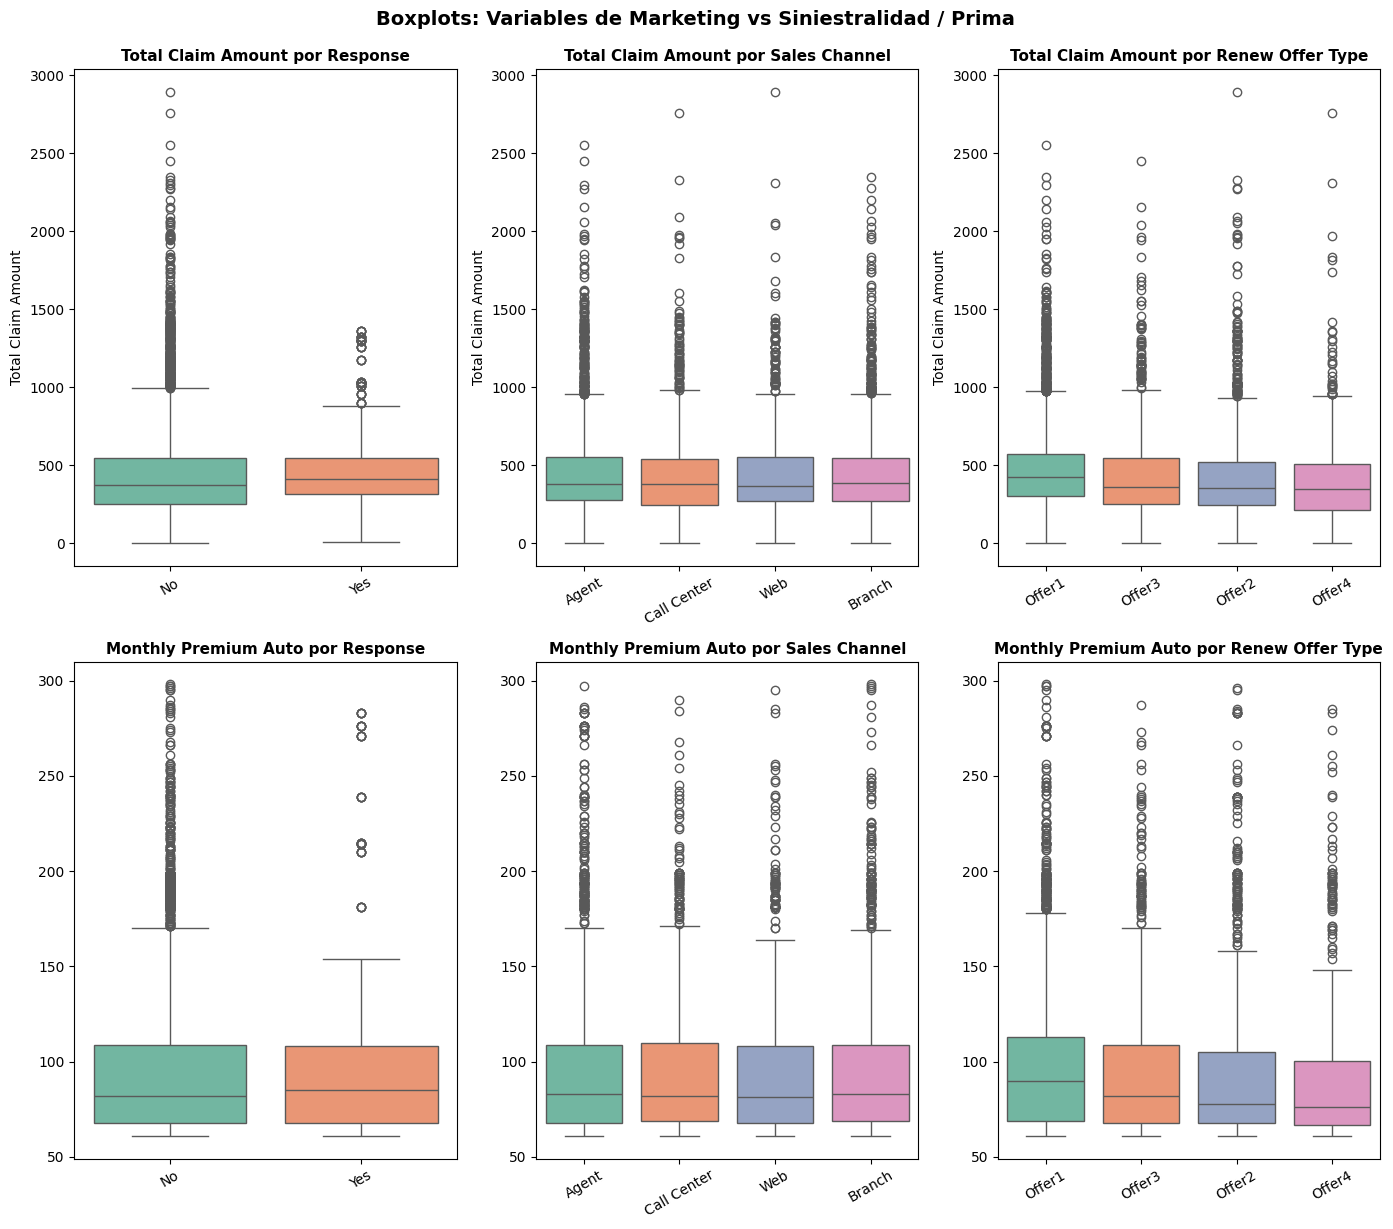

In [9]:
# Variables de agrupación (marketing) y variables objetivo
group_vars = ['Response', 'Sales Channel', 'Renew Offer Type']
target_vars = ['Total Claim Amount', 'Monthly Premium Auto']

# --- Boxplots ---
fig, axes = plt.subplots(nrows=len(target_vars), ncols=len(group_vars), figsize=(14, 12))

for i, grp in enumerate(group_vars):
    for j, tgt in enumerate(target_vars):
        ax = axes[j, i]
        sns.boxplot(
            data=df_limpio,
            x=grp,
            y=tgt,
            hue=grp,
            ax=ax,
            legend=False,
            palette='Set2'
        )
        ax.set_title(f'{tgt} por {grp}', fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(tgt if j == 0 else '')
        ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.suptitle('Boxplots: Variables de Marketing vs Siniestralidad / Prima',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()



En general parece que los distintos niveles de cada una de las variables de Marketing siguen la misma distribución y en consecuencia no son relevantes sobre nuestras posibles variables dependientes. Usamos el test de Kruskal-Walis que establece la siguiente hipótesis nula:
- Ho: Las medianas de los distintos niveles son iguales.

Usamos este test no paramétrico pues no asume normalidad, más adelante comprobaremos que nuestras variables numéricas no son normales.

In [10]:

print("TEST DE KRUSKAL-WALLIS")

alpha = 0.05
kruskal_results = []

for grp in group_vars:
    niveles = sorted(df_limpio[grp].unique())
    for tgt in target_vars:
        samples = [df_limpio.loc[df_limpio[grp] == n, tgt].dropna().values for n in niveles]
        stat, p_val = kruskal(*samples)
        sig = "✅ SÍ" if p_val < alpha else "❌ NO"
        kruskal_results.append({'Agrupación': grp, 'Target': tgt,
                                 'p-valor': round(p_val, 6), f'Sig. ({alpha})': sig})

display(pd.DataFrame(kruskal_results))


TEST DE KRUSKAL-WALLIS


,Agrupación,Target,p-valor,Sig. (0.05)
0,Response,Total Claim Amount,0.000008,✅ SÍ
1,Response,Monthly Premium Auto,0.397290,❌ NO
2,Sales Channel,Total Claim Amount,0.818440,❌ NO
3,Sales Channel,Monthly Premium Auto,0.608168,❌ NO
4,Renew Offer Type,Total Claim Amount,0.000000,✅ SÍ
5,Renew Offer Type,Monthly Premium Auto,0.000000,✅ SÍ


**Interpretación de los resultados y decisión de exclusión:**

El test revela que `Sales Channel` no discrimina en ninguna combinación (p > 0.60) — es ruido puro. Sin embargo, `Response` y `Renew Offer Type` sí muestran diferencias significativas en la severidad total.

La razón por la que se excluyen igualmente es **actuarial, no estadística**: estas dos variables son **métricas de resultado**, no de riesgo a priori:
- `Renew Offer Type` se determina *a posteriori* de la severidad observada y del perfil tarifario del cliente — es consecuencia del riesgo, no causa.
- `Response` recoge la reacción del cliente a una campaña, que a su vez está condicionada por su historial de siniestros. La correlación es inversa a la que necesitamos para modelar.

Incluirlas como predictoras induciría **fuga de información** (*data leakage*) en la BNN.

In [11]:
# Eliminamos las variables de marketing y la variable Policy original
df_1 = df_limpio.copy().drop(columns=['Policy', 'Response', 'Sales Channel', 'Renew Offer Type'])
print(f"Dataset tras eliminar variables de marketing: {df_1.shape}")

Dataset tras eliminar variables de marketing: (8971, 20)


#### 2.3. Análisis de `Policy Level`: ¿aporta información adicional?

Antes de decidir si `Policy Level` tiene capacidad discriminatoria sobre la siniestralidad, cruzamos sus niveles con la cobertura, la prima y la severidad.

In [12]:
resumen_cruzado = pd.pivot_table(
    df_1,
    values=['Monthly Premium Auto', 'Total Claim Amount'],
    index='Coverage',
    columns='Policy Level',
    aggfunc='mean'
).reindex(['Basic', 'Extended', 'Premium'])

print("--- Medias de Severidad y Prima por Cobertura y Nivel de Póliza ---")
display(resumen_cruzado.round(2))

# Test Kruskal: ¿Policy Level discrimina la severidad?
samples_level = [df_1.loc[df_1['Policy Level'] == n, 'Total Claim Amount'].values
                 for n in sorted(df_1['Policy Level'].unique())]
stat_pl, p_pl = kruskal(*samples_level)
print(f"\nKruskal-Wallis de Policy Level sobre Total Claim Amount: p = {p_pl:.4f}")
print("Conclusión:", "Discrimina la severidad." if p_pl < 0.05 else "No discrimina la severidad.")

--- Medias de Severidad y Prima por Cobertura y Nivel de Póliza ---


Monthly Premium Auto                 Total Claim Amount          \
Policy Level              Level 1 Level 2 Level 3            Level 1 Level 2   
Coverage                                                                       
Basic                       81.31   82.51   82.35             382.64  378.36   
Extended                   106.23  103.19  102.59             507.07  485.23   
Premium                    132.02  127.80  137.98             620.95  629.19   

                      
Policy Level Level 3  
Coverage              
Basic         378.06  
Extended      465.71  
Premium       683.20


Kruskal-Wallis de Policy Level sobre Total Claim Amount: p = 0.4738
Conclusión: No discrimina la severidad.


Los niveles de `Policy Level` no muestran ningún patrón claro de progresión en la severidad ni en la prima una vez controlado el tipo de cobertura, y el test confirma que no aporta capacidad discriminatoria adicional. Se descarta.

In [13]:
df_1 = df_1.drop(columns=['Policy Level'])

#### 2.4. Distribución de frecuencias de las variables categóricas nominales

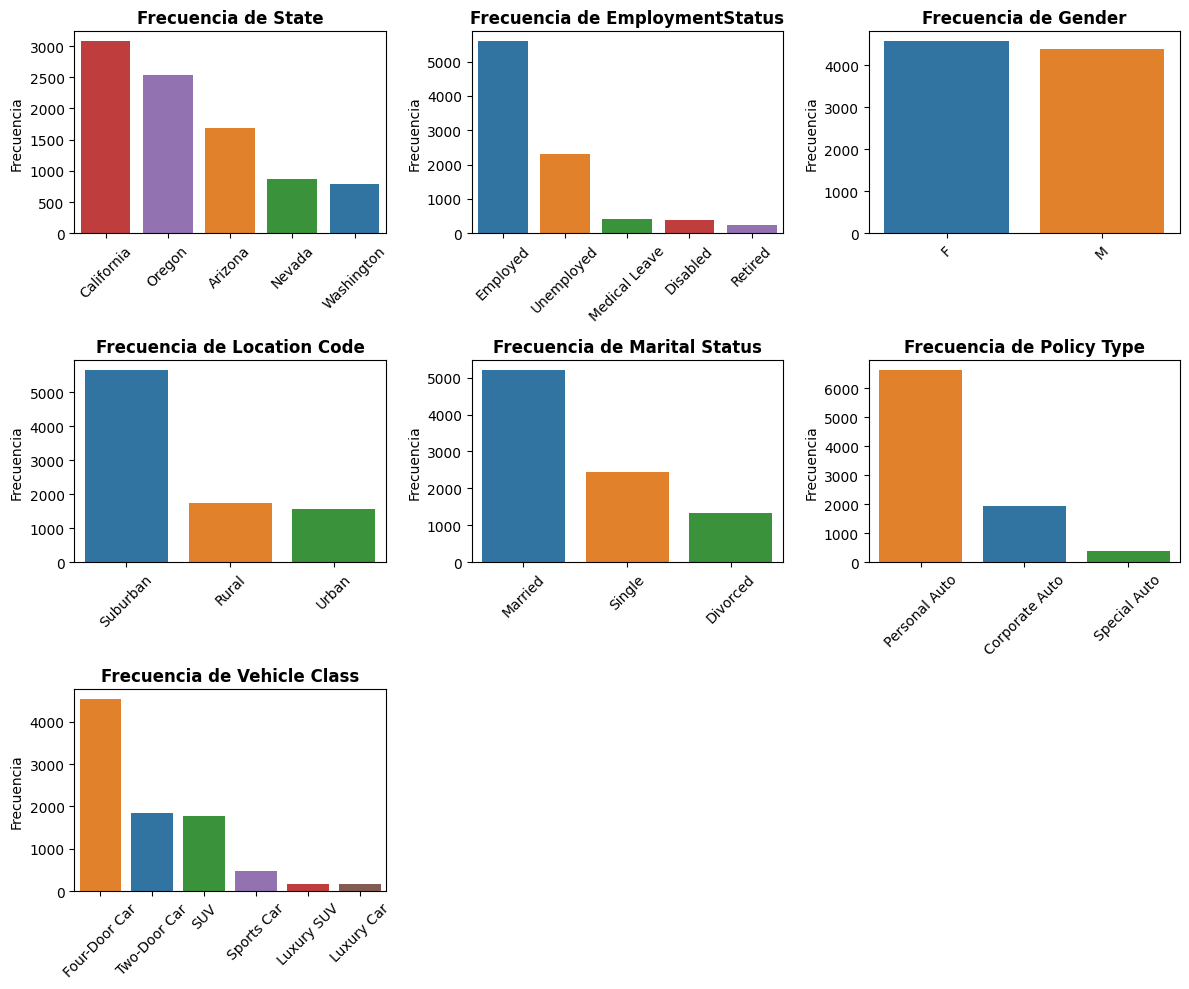

In [14]:
# Dibujar gráfico de barras para cada variable categórica
nominal_columns = ['State', 'EmploymentStatus', 'Gender', 'Location Code', 'Marital Status', 'Policy Type', 'Vehicle Class']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(nominal_columns):
    # Crear el gráfico en el eje específico (ax=axes[i])
    sns.countplot(
        data=df_1,
        x=col, 
        hue=col, 
        order=df_1[col].value_counts().index, 
        ax=axes[i],
        legend= False
    )
    
    # Configurar títulos y etiquetas para cada subgráfico
    axes[i].set_title(f'Frecuencia de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('') # Quitamos el nombre del eje X para no saturar
    axes[i].set_ylabel('Frecuencia')
    
    # Rotar las etiquetas del eje X si son muy largas
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(nominal_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Evitar solapamiento de subgráficos
plt.show()

#### 2.4. Distribución de frecuencias de las variables categóricasordinales

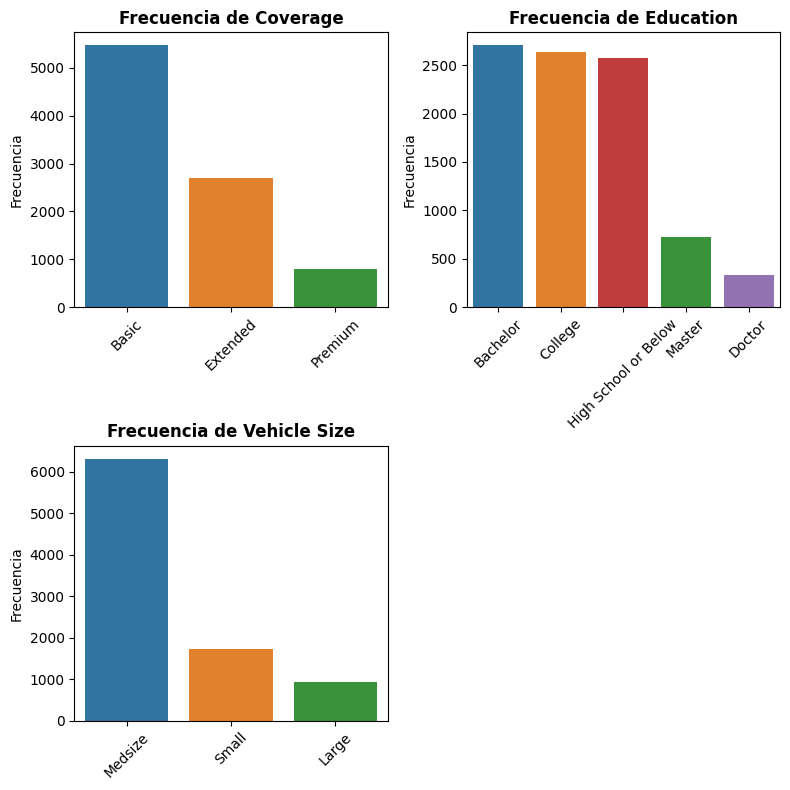

In [15]:
# Dibujar gráfico de barras para cada variable categórica
ordinal_columns = ['Coverage', 'Education', 'Vehicle Size']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
axes = axes.flatten()
for i, col in enumerate(ordinal_columns):
    # Crear el gráfico en el eje específico (ax=axes[i])
    sns.countplot(
        data=df_1,
        x=col, 
        hue=col, 
        order=df_1[col].value_counts().index, 
        ax=axes[i],
        legend= False
    )
    
    # Configurar títulos y etiquetas para cada subgráfico
    axes[i].set_title(f'Frecuencia de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('') # Quitamos el nombre del eje X para no saturar
    axes[i].set_ylabel('Frecuencia')
    
    # Rotar las etiquetas del eje X si son muy largas
    axes[i].tick_params(axis='x', rotation=45)
    
for j in range(len(ordinal_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Evitar solapamiento de subgráficos
plt.show()

#### 2.5. Severidad media por nivel de cada variable categórica

Las frecuencias de las categorías no son suficientes — necesitamos saber si los distintos niveles producen perfiles de severidad diferentes. Este análisis es el precursor visual del ANOVA que se realiza en el notebook de reducción de dimensionalidad.

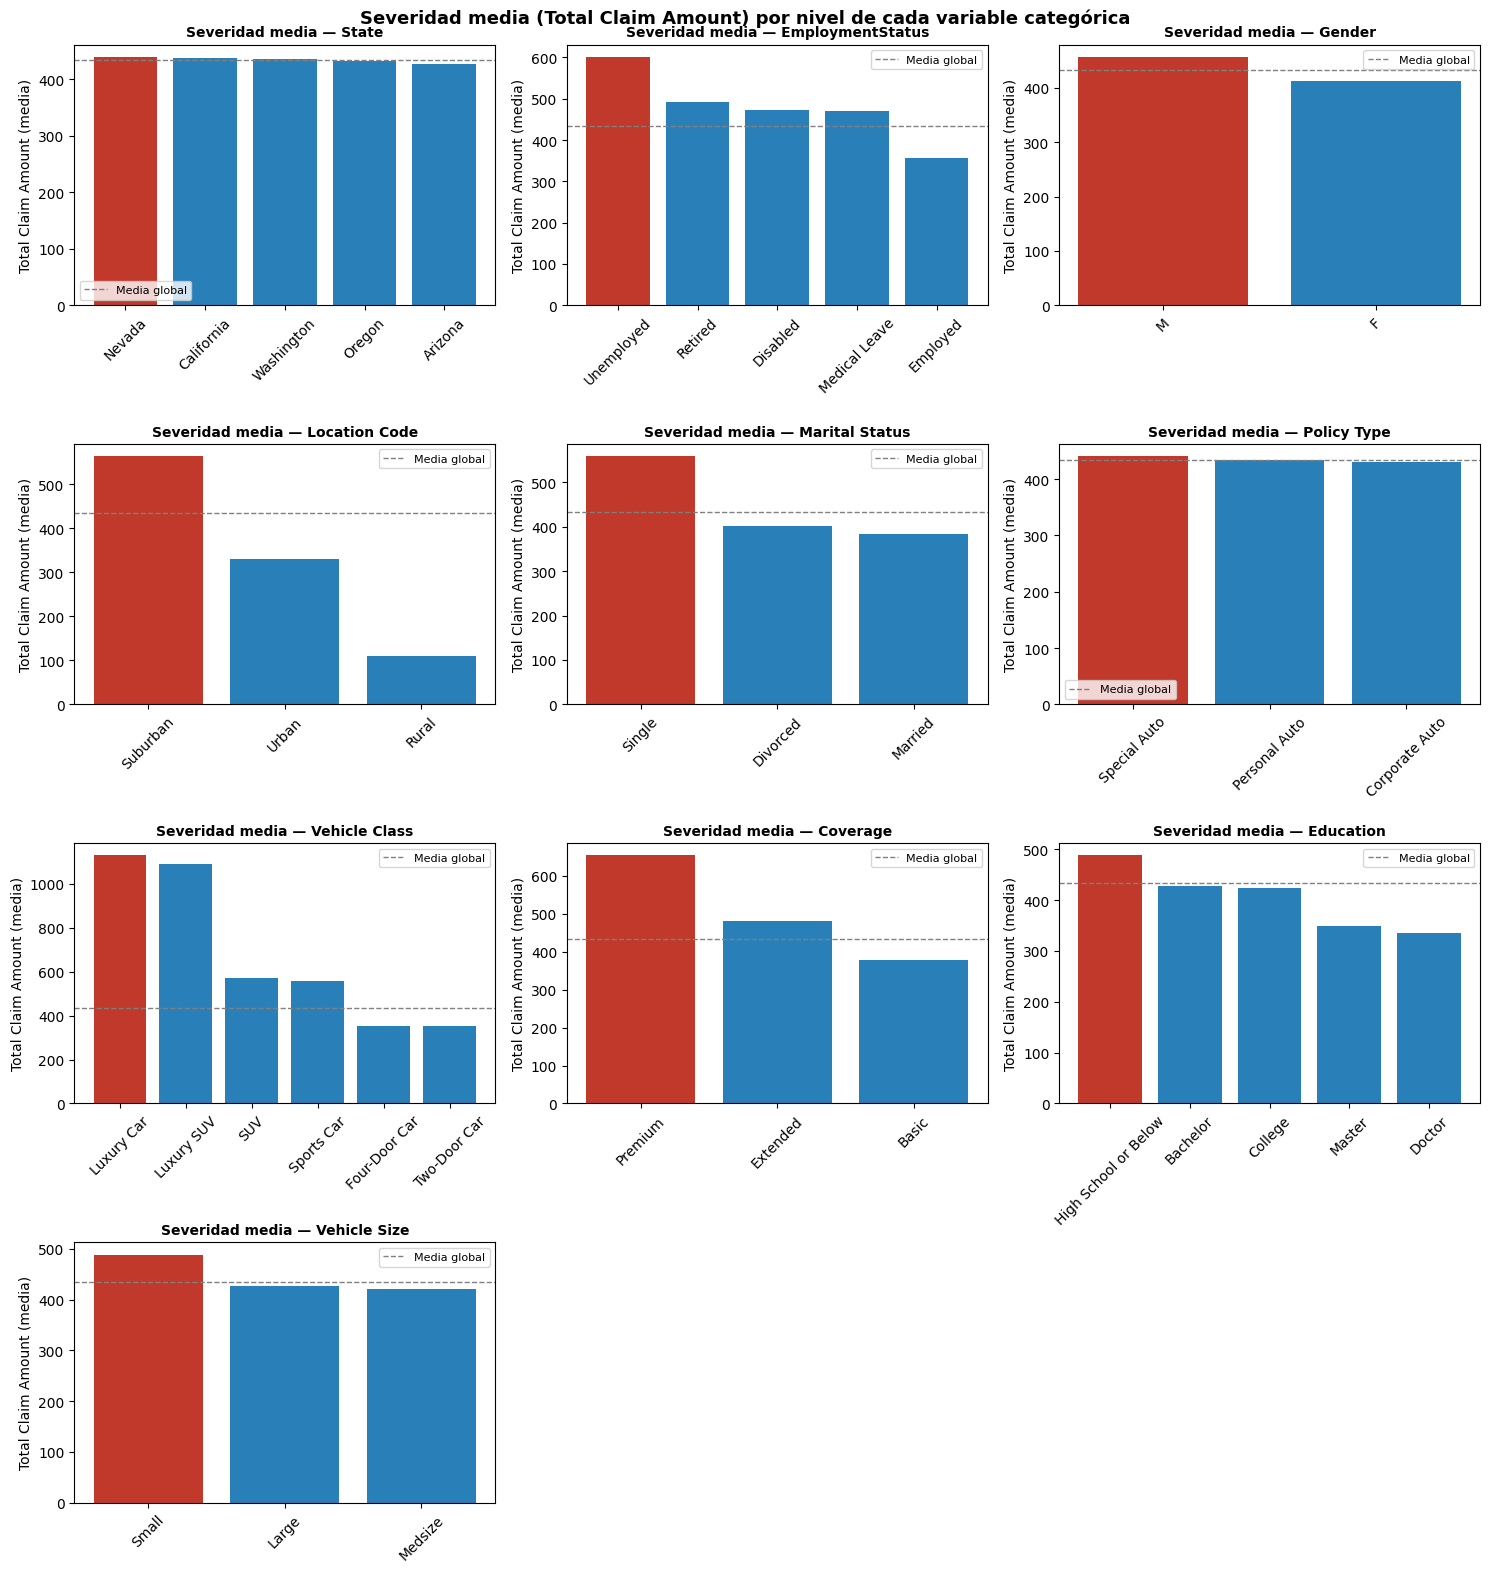

In [16]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 16))
axes = axes.flatten()

all_cat_columns = nominal_columns + ordinal_columns

for i, col in enumerate(all_cat_columns):
    means  = df_1.groupby(col)['Total Claim Amount'].mean().sort_values(ascending=False)
    colors = ['#c0392b' if v == means.max() else '#2980b9' for v in means.values]
    axes[i].bar(means.index, means.values, color=colors)
    axes[i].axhline(df_1['Total Claim Amount'].mean(), color='grey',
                    linestyle='--', linewidth=1, label='Media global')
    axes[i].set_title(f'Severidad media — {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Total Claim Amount (media)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=8)

for j in range(len(all_cat_columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Severidad media (Total Claim Amount) por nivel de cada variable categórica',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 3. VARIABLES NUMÉRICAS

Identificamos y definimos nuestras variables numéricas:

- `Customer Lifetime Value`. Toma valores decimales, representa el valor presente neto que generará el cliente durante toda su relación con la aseguradora. 
- `Income`. El ingreso anual reportado por el cliente, toma valores enteros.
- `Monthly Premium Auto`. Es la prima mensual que paga el cliente por su seguro de coche. Toma valores enteros
- `Months Since Last Claim`. El número de meses que han transcurrido desde la última reclamación. Es una variable discreta
- `Months Since Policy Inception`. El número de meses desde que el cliente contrató la póliza. Es una variable discreta.
- `Number of Open Complaints`. El número de reclamaciones activas o abiertas, es un valor entero (variable discreta)
- `Number of Policies`. El número de pólizas que el cliente tiene contratadas con la aseguradora, el número de vehículos asegurados, toma valores enteros y es una variable discreta.
- `Total Claim Ammunt`. Cuantía total acumulada que la aseguradora ha pagado por los reclamos de ese cliente

#### 3.1. Estadísticos descriptivos




In [17]:
numerical_columns = ['Customer Lifetime Value', 'Income', 'Monthly Premium Auto', 
            'Months Since Last Claim', 'Months Since Policy Inception', 
            'Number of Open Complaints', 'Number of Policies', 'Total Claim Amount']

df_num = df_1[numerical_columns].copy()
display(df_num.describe().round(2))

,Customer Lifetime Value,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Total Claim Amount
count,8971.00,8971.00,8971.00,8971.00,8971.00,8971.00,8971.00,8971.00
mean,8004.19,37644.83,93.19,15.10,48.05,0.39,2.97,433.89
std,6867.94,30431.74,34.36,10.08,27.92,0.91,2.39,291.07
min,1898.01,0.00,61.00,0.00,0.00,0.00,1.00,0.10
25%,3999.50,0.00,68.00,6.00,24.00,0.00,1.00,270.47
50%,5792.44,33947.00,83.00,14.00,48.00,0.00,2.00,383.44
75%,8954.64,62365.50,109.00,23.00,71.00,0.00,4.00,547.98
max,83325.38,99981.00,298.00,35.00,99.00,5.00,9.00,2893.24


En este pequeño resumen estadístico apreciamos algunos valores que requieren atención:
- `Income` tiene un cuartil 25% en 0 — se investiga a continuación.
- `Total Claim Amount` mínimo es ~0.10 — valores anómalos que se tratarán en la sección 3.4.
- `Number of Open Complaints` es 0 para más del 75% de la muestra — distribución fuertemente concentrada.

#### 3.2. Distribuciones e histogramas

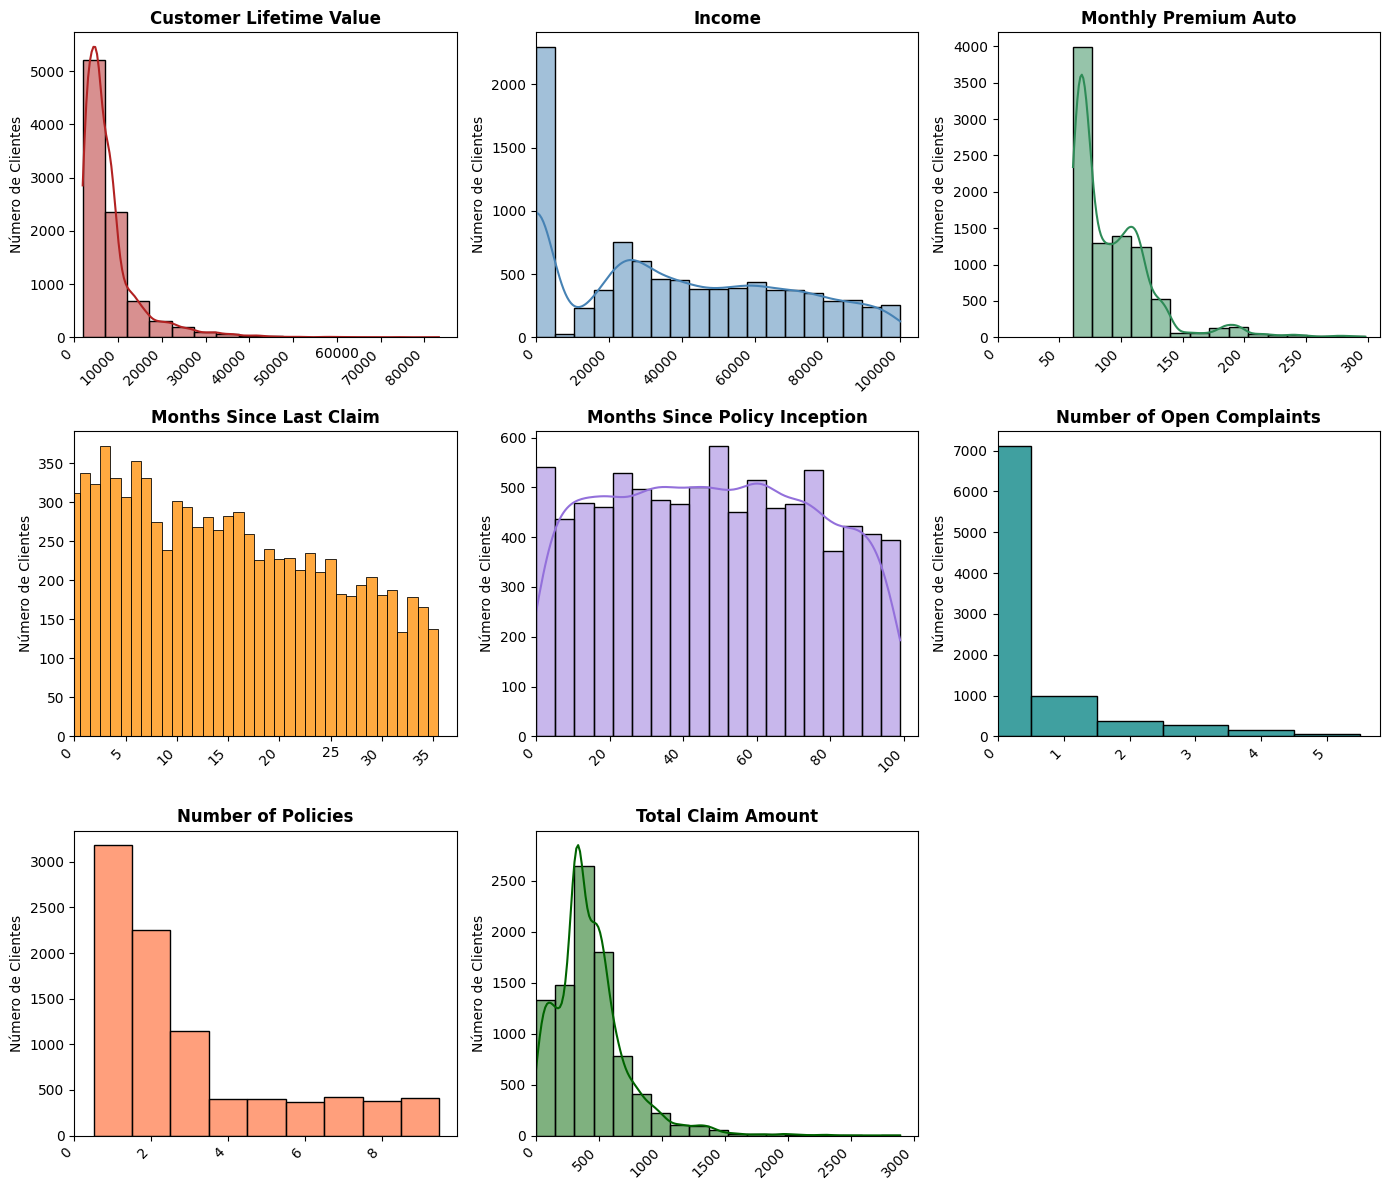

In [18]:
# Dibujar histogramas para cada variable numérica

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 12))
axes = axes.flatten()
colors = ['firebrick', 'steelblue', 'seagreen', 'darkorange', 
          'mediumpurple', 'teal', 'coral', 'darkgreen']

for i, col in enumerate(numerical_columns):
    # Ajustamos el tamaño de los intervalos del histograma utilizando el máximo y mínimo de cada variable para definir los bins
    min_val = df_num[col].min()
    max_val = df_num[col].max()

    if max_val - min_val < 50:      # Si el rango es menor a 50, usamos un bin por cada unidad
        sns.histplot(data=df_num, x=col, ax=axes[i], discrete=True, # Centra y ensancha las barras en los números enteros
            kde=False,     # La curva de densidad no aporta mucho en datos discretos
            color=colors[i]
        )
    else:
        if max_val - min_val < 100:   # Si el rango es menor a 500, usamos un bin por cada 25 unidades
            nbins = int((max_val - min_val) / 5)
        elif max_val - min_val < 500:   # Si el rango es menor a 500, usamos un bin por cada 25 unidades
            nbins = int((max_val - min_val) / 15)
        elif max_val - min_val < 10000:  # Si el rango es menor a 1000, usamos un bin por cada 50 unidades
            nbins = int((max_val - min_val) / 150)
        else:                           # Si el rango es mayor a 1000, usamos un bin por cada 100 unidades
            nbins = int((max_val - min_val) / 5000)

        sns.histplot(data=df_num, x=col,  ax=axes[i],
            bins=nbins, kde=True, color=colors[i])
    
    # Configurar títulos y etiquetas para cada subgráfico
    axes[i].set_xlim(left=0)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('') # Quitamos el nombre del eje X para no saturar
    axes[i].set_ylabel('Número de Clientes')
    
    # Rotar las etiquetas del eje X si son muy largas
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')

for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Evitar solapamiento de subgráficos
plt.show()

#### 3.3. Análisis de `Income == 0` — validación con `EmploymentStatus`

In [19]:
print(f"Registros con Income = 0: {(df_1['Income'] == 0).sum():,} "      f"({(df_1['Income'] == 0).mean()*100:.1f}% del total)\n")

cross_tab = pd.crosstab(df_1['EmploymentStatus'], df_1['Income'] == 0,
                        colnames=['Income == 0'])
print(cross_tab)

non_unemployed_zero = df_1[(df_1['Income'] == 0) & (df_1['EmploymentStatus'] != 'Unemployed')]
print(f"\nClientes no desempleados con Income=0: {len(non_unemployed_zero)}")
print("Conclusión: todos los Income=0 corresponden exclusivamente a desempleados. "      "El valor es coherente con el negocio.")

Registros con Income = 0: 2,296 (25.6% del total)

Income == 0       False  True 
EmploymentStatus              
Disabled            397      0
Employed           5604      0
Medical Leave       420      0
Retired             254      0
Unemployed            0   2296

Clientes no desempleados con Income=0: 0
Conclusión: todos los Income=0 corresponden exclusivamente a desempleados. El valor es coherente con el negocio.


El 25.6% de los registros son desempleados con `Income = 0`. Esto implica que `Income` sigue una **distribución zero-inflated**: una masa de punto en 0 y una distribución continua para el resto. Esta característica es relevante para el BNN posterior y para la codificación en el notebook de dimensionalidad, donde se gestionará la colinealidad que introduce con `EmploymentStatus`.

#### 3.4. Detección de outliers

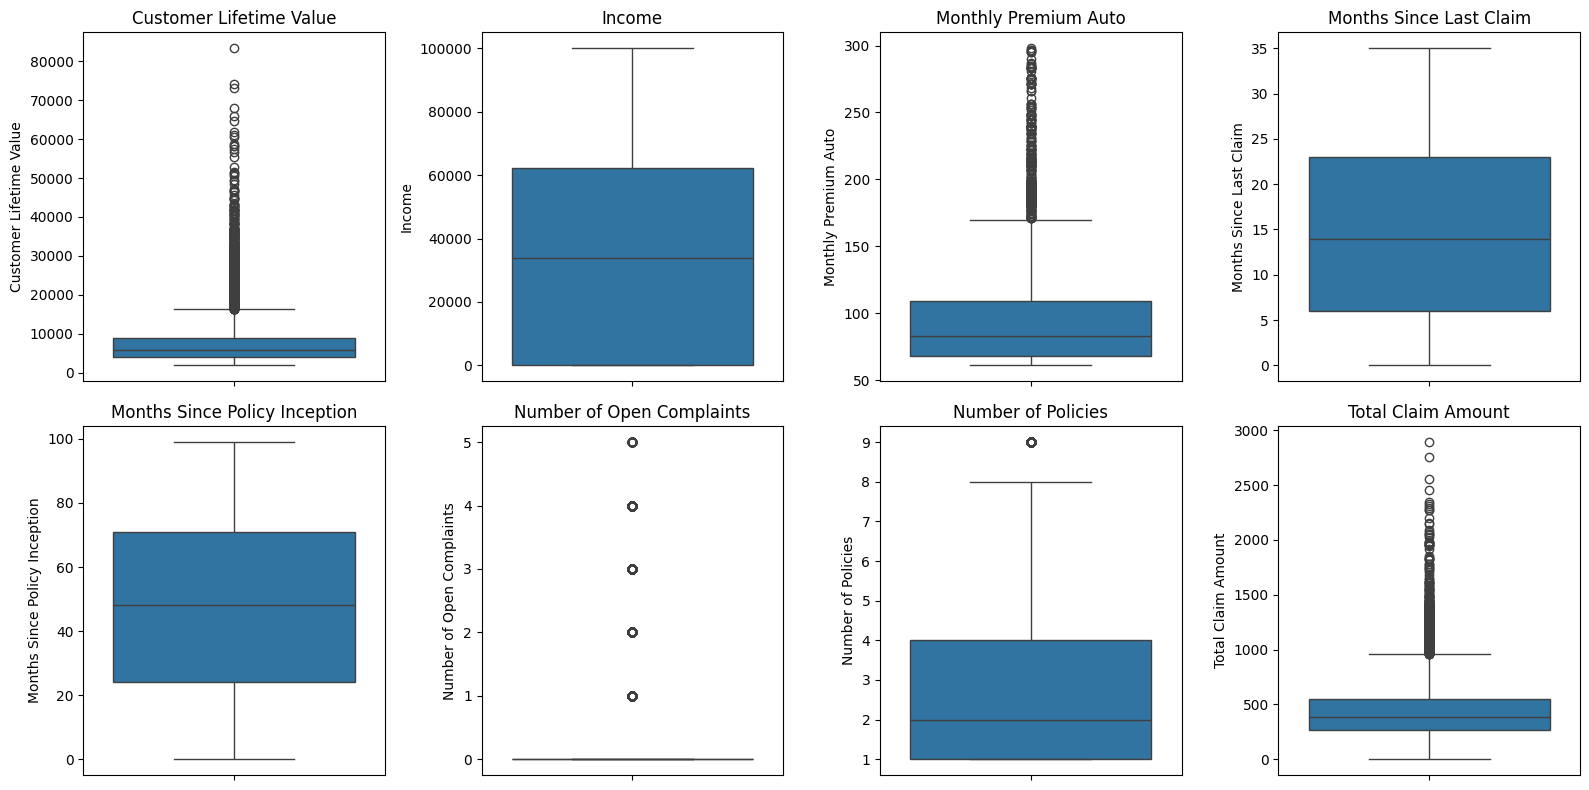

In [20]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(numerical_columns):
    ax = axes[i // 4, i % 4]
    sns.boxplot(data=df_1, y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Vemos que existen outliers en la mayoría de nuestras variables. Algunos de estos outliers son de relevancia como por ejemplo en la variable `Total Claim Amount` donde los siniestros de severidad muy elevada son fundamentales para el cálculo de la reserva. En otras variables, dependiendo de los modelos que usemos quizá sea de interés aplicar escaladados y/o transformaciones logarítmicas. Vamos a chequear tambien cuantas observaciones son consideradas outliers para cada variable:

In [21]:
print("\n── Cuantificación de outliers (IQR × 1.5) ──")
outlier_summary = []
for col in numerical_columns:
    Q1, Q3 = df_num[col].quantile(0.25), df_num[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_num[col] < Q1 - 1.5*IQR) | (df_num[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({'Variable': col, 'N outliers': n_out,
                             '% del total': round(n_out/len(df_num)*100, 1),
                             'Estrategia': 'Conservar (colas relevantes para reservas)' if col == 'Total Claim Amount'
                                           else 'Conservar — transformación en pipeline' if col in ['Customer Lifetime Value', 'Monthly Premium Auto']
                                           else 'Conservar — variable discreta acotada'})
display(pd.DataFrame(outlier_summary))


── Cuantificación de outliers (IQR × 1.5) ──


,Variable,N outliers,% del total,Estrategia
0,Customer Lifetime Value,802,8.9,Conservar — transformación en pipeline
1,Income,0,0.0,Conservar — variable discreta acotada
2,Monthly Premium Auto,423,4.7,Conservar — transformación en pipeline
3,Months Since Last Claim,0,0.0,Conservar — variable discreta acotada
4,Months Since Policy Inception,0,0.0,Conservar — variable discreta acotada
5,Number of Open Complaints,1857,20.7,Conservar — variable discreta acotada
6,Number of Policies,410,4.6,Conservar — variable discreta acotada
7,Total Claim Amount,442,4.9,Conservar (colas relevantes para reservas)


- `Total Claim Amount`: los siniestros de severidad extrema son exactamente el objeto de estudio de la BNN de reservas. Winsorizar o eliminar estas observaciones sesgaría la estimación del margen de riesgo. Se conservan y la asimetría de la distribución se captura mediante la elección de la familia de distribuciones (ver sección 3.7).
- `Customer Lifetime Value` y `Monthly Premium Auto`: asimetría moderada-alta que se gestionará mediante estandarización o transformación logarítmica en el pipeline de preprocesamiento.
- `Number of Open Complaints`: el 20.7% de outliers por IQR es consecuencia de la concentración del 79% de los registros en 0. Es una variable discreta acotada — los valores 1-5 son razonables para quejas abiertas en una cartera activa.

#### 3.5. Test de normalidad (Anderson-Darling)
Llevamos a cabo el test de Anderson_daling para comprobar si nuestras variables numéricas siguen una normal pues tenemos indicios de lo contrario. Se escoge este test frente a otros como Shapiro-Wilkinson porque es más potentes para muestras grandes

In [22]:

print("── Test de Anderson-Darling (H₀: la variable sigue una distribución normal) ──\n")

norm_results = []
for col in numerical_columns:
    data = df_num[col].dropna()
    res  = anderson(data, dist='norm')
    # Nivel de significación del 5% -> índice 2 en critical_values
    rechaza_H0 = res.statistic > res.critical_values[2]
    norm_results.append({
        'Variable': col,
        'Estadístico A²': round(res.statistic, 2),
        'Crítico 5%': res.critical_values[2],
        'Rechaza H₀ (normal)': 'SÍ' if rechaza_H0 else 'NO',
        'Skewness': round(data.skew(), 2),
        'Kurtosis': round(data.kurtosis(), 2)
    })

display(pd.DataFrame(norm_results))


── Test de Anderson-Darling (H₀: la variable sigue una distribución normal) ──



C:\Users\perez\AppData\Local\Temp\ipykernel_16476\2904906141.py:6: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res  = anderson(data, dist='norm')


,Variable,Estadístico A²,Crítico 5%,Rechaza H₀ (normal),Skewness,Kurtosis
0,Customer Lifetime Value,695.24,0.752,SÍ,3.04,13.97
1,Income,194.95,0.752,SÍ,0.29,-1.10
2,Monthly Premium Auto,445.70,0.752,SÍ,2.12,6.14
3,Months Since Last Claim,115.91,0.752,SÍ,0.28,-1.07
4,Months Since Policy Inception,81.40,0.752,SÍ,0.04,-1.13
5,Number of Open Complaints,1998.09,0.752,SÍ,2.77,7.70
6,Number of Policies,744.60,0.752,SÍ,1.25,0.36
7,Total Claim Amount,176.97,0.752,SÍ,1.72,6.02


Conclusión: ninguna variable sigue una distribución normal.
Implicaciones:
- Tests de hipótesis sobre las variables numéricas: se usan tests no paramétricos (Kruskal-Wallis)
- Transformaciones necesarias: estandarización robusta o log-transformación para variables con alta asimetría."
- De cara a la BNN: la función de verosimilitud no puede ser gaussiana (ver sección 3.6).

#### 3.6. Análisis de la distribución del target: `Total Claim Amount`

Evaluamos tres candidatas habituales para severidad de siniestros: **Gamma**, **Lognormal** y **Weibull**, conocer la distribución de la variable objetovp será necesario para el GLM y la BNN.

--- Ajuste de distribuciones de severidad (Kolmogorov-Smirnov) ---
  Gamma:    KS = 0.1246 
  Lognormal: KS = 0.1799
  Weibull:  KS = 0.1047


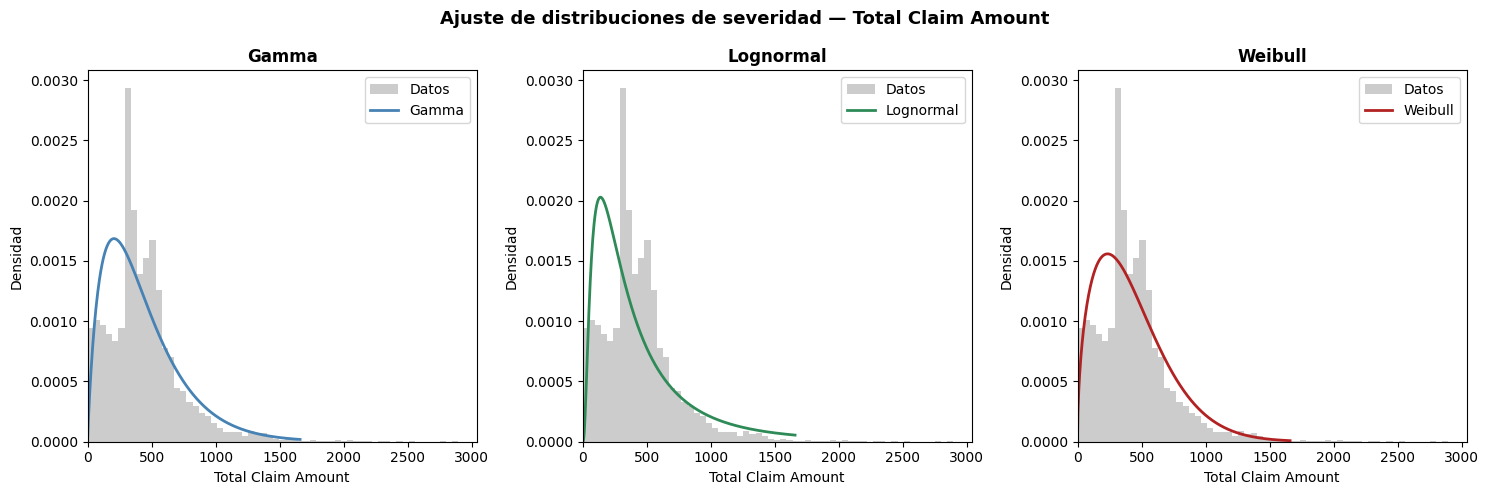

In [24]:
tca = df_num['Total Claim Amount'].values

# --- Ajuste de distribuciones ---
gfit  = gamma.fit(tca, floc=0)
lfit  = lognorm.fit(tca, floc=0)
wfit  = weibull_min.fit(tca, floc=0)

ks_g, p_g = kstest(tca, 'gamma',      args=gfit)
ks_l, p_l = kstest(tca, 'lognorm',    args=lfit)
ks_w, p_w = kstest(tca, 'weibull_min', args=wfit)

print("--- Ajuste de distribuciones de severidad (Kolmogorov-Smirnov) ---")
print(f"  Gamma:    KS = {ks_g:.4f} ")
print(f"  Lognormal: KS = {ks_l:.4f}")
print(f"  Weibull:  KS = {ks_w:.4f}")

# --- Visualización ---
x = np.linspace(tca.min(), np.percentile(tca, 99.5), 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dist_configs = [
    ('Gamma',    gamma,       gfit,  'steelblue'),
    ('Lognormal', lognorm,    lfit,  'seagreen'),
    ('Weibull',  weibull_min, wfit,  'firebrick'),
]

for ax, (name, dist_obj, fit_params, color) in zip(axes, dist_configs):
    ax.hist(tca, bins=60, density=True, alpha=0.4, color='grey', label='Datos')
    ax.plot(x, dist_obj.pdf(x, *fit_params), color=color, lw=2, label=name)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Total Claim Amount')
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.set_xlim(left=0)

plt.suptitle('Ajuste de distribuciones de severidad — Total Claim Amount',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Weibull obtiene el mejor ajuste de KS al obtener el estadístico más bajo. Comprobemos los gráficos Q-Q.

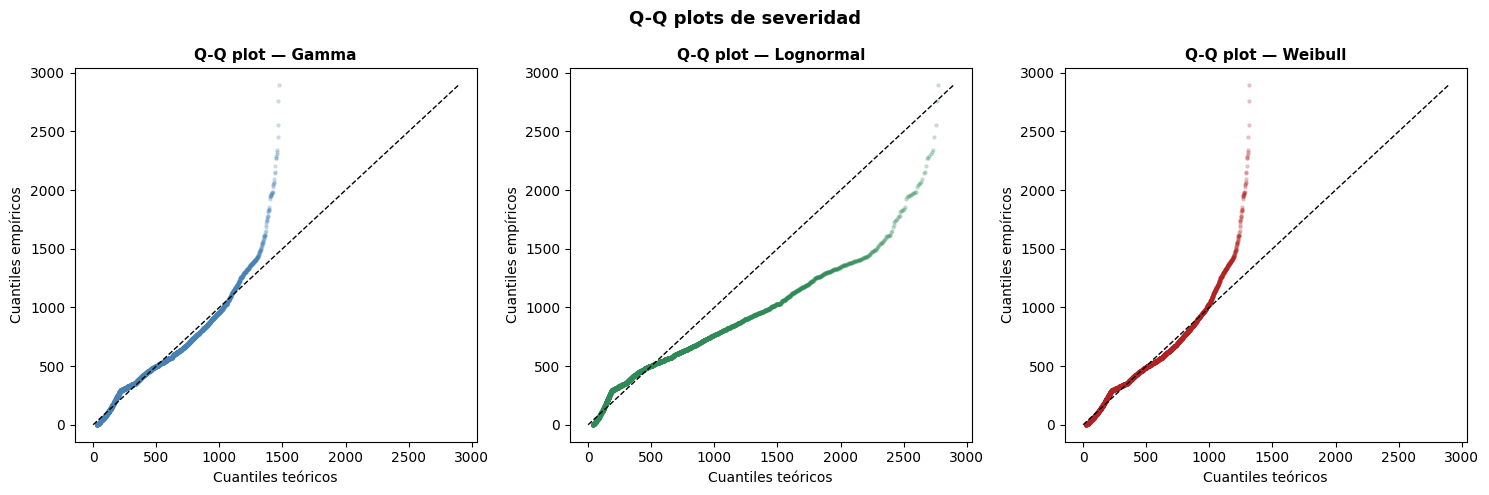

In [25]:
# --- Q-Q plots para las tres distribuciones ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, dist_obj, fit_params, color) in zip(axes, dist_configs):
    theoretical_q = dist_obj.ppf(np.linspace(0.01, 0.99, len(tca)), *fit_params)
    empirical_q   = np.sort(tca)
    ax.scatter(theoretical_q, empirical_q, alpha=0.2, s=5, color=color)
    lim = max(theoretical_q.max(), empirical_q.max())
    ax.plot([0, lim], [0, lim], 'k--', lw=1)
    ax.set_title(f'Q-Q plot — {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles empíricos')

plt.suptitle('Q-Q plots de severidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Si observamos los gráficos Q-Q plot vemos que tanto Weibull como Gamma se adaptan muy bien al cuerpo de la distribución; sin embargo ambas acaban subestimando la cola. De cara al futuro GLM y BNN no podemos usar estas distribuciones únicamente, estas distribs predecirán la masa principal de la distribución mientras que la cola la estimaremos usando Teoría de Valores Extremos (EVT)

### 4. ANÁLISIS DE CORRELACIONES

Calculamos la matriz de correlaciones sobre el dataset ya limpio (con los registros anómalos eliminados).

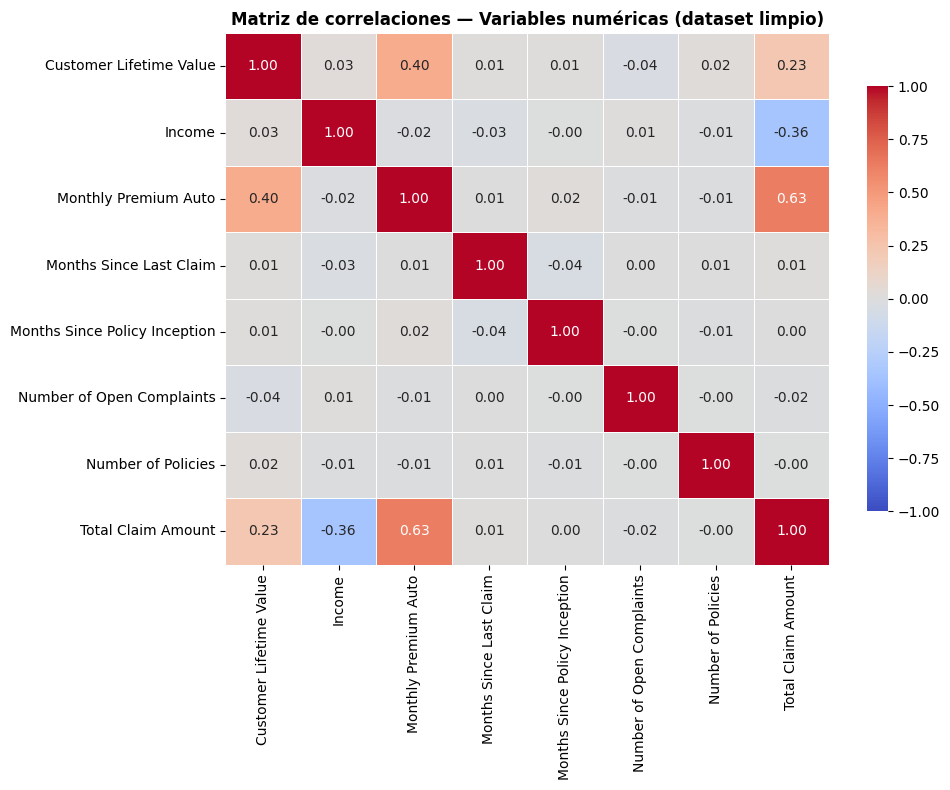

Pares con correlación absoluta > 0.3:
Monthly Premium Auto     Total Claim Amount      0.630994
Customer Lifetime Value  Monthly Premium Auto    0.398702
Income                   Total Claim Amount     -0.355936


In [26]:
corr_matrix = df_num.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)
plt.title('Matriz de correlaciones — Variables numéricas (dataset limpio)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Pares con |r| > 0.3
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[(corr_pairs < 0.999) & (corr_pairs.abs() > 0.3)].drop_duplicates()
print("Pares con correlación absoluta > 0.3:")
print(corr_pairs.sort_values(key=abs, ascending=False).to_string())

La correlación más alta (r ≈ 0.64) es entre `Monthly Premium Auto` y `Total Claim Amount`. Aunque estadísticamente notable, esta relación es de **causalidad inversa**: la prima se fija en función del riesgo esperado del cliente, que a su vez se estima en base a la siniestralidad histórica. Incluir la prima como predictor de la severidad induciría razonamiento circular. Esta decisión se documenta y justifica formalmente en el notebook de reducción de dimensionalidad.

### 5. GUARDADO DEL DATASET PROCESADO

In [28]:
output_path = "../data/processed/"
df_1.to_csv(output_path + "df_limpio.csv", index=False)

print(f"Dataset limpio guardado: {len(df_1):,} registros × {len(df_1.columns)} columnas.")
print(f"\nTipos de datos:")
print(df_1.dtypes)
print(f"\nResumen final:")
print(f"  Registros eliminados (duplicados)  : {len(df_original) - len(df_limpio):,}")
print(f"  Variables eliminadas               : Policy, Response, Sales Channel, Renew Offer Type, Policy Level, Effective To Date")

Dataset limpio guardado: 8,971 registros × 19 columnas.

Tipos de datos:
Customer                             str
State                                str
Customer Lifetime Value          float64
Coverage                             str
Education                            str
EmploymentStatus                     str
Gender                               str
Income                             int64
Location Code                        str
Marital Status                       str
Monthly Premium Auto               int64
Months Since Last Claim            int64
Months Since Policy Inception      int64
Number of Open Complaints          int64
Number of Policies                 int64
Policy Type                          str
Total Claim Amount               float64
Vehicle Class                        str
Vehicle Size                         str
dtype: object

Resumen final:
  Registros eliminados (duplicados)  : 163
  Variables eliminadas               : Policy, Response, Sales Channel, Ren